# 06 - EDA: Sentiment Driver Discovery
## ShopEase Europe | Sentiment Analysis Project
**Objective:** Identify the specific words and phrases driving positive 
and negative sentiment across customer reviews. These insights translate 
directly into actionable recommendations for product and operations teams.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'clean_reviews.csv')
FIGURES_PATH = os.path.join(PROJECT_ROOT, 'reports', 'figures')

df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 120,000 rows x 14 columns


## Most Frequent Words by Sentiment
Identifying the words customers use most when leaving positive, 
negative and neutral reviews, revealing what drives satisfaction 
and dissatisfaction at a granular level.

In [4]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

# Multilingual stop words
all_stops = set()
for lang in ['english', 'french', 'german', 'spanish']:
    all_stops.update(stopwords.words(lang))

# Add custom noise words
custom_stops = {'de', 'je', 'la', 'el', 'le', 'les', 'un', 'una',
                'que', 'es', 'en', 'du', 'au', 'se', 'sehr', 
                'très', 'muy', 'ist', 'als', 'wie', 'auch'}
all_stops.update(custom_stops)

def clean_and_count(text, n=15):
    words = text.lower().split()
    # Remove stop words and punctuation
    words = [w.strip('.,!?;:\'"()[]') for w in words]
    words = [w for w in words if w not in all_stops and len(w) > 2]
    return Counter(words).most_common(n)

# Separate reviews by sentiment
positive_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'].astype(str))
negative_text = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'].astype(str))
neutral_text = ' '.join(df[df['sentiment'] == 'neutral']['cleaned_review'].astype(str))

print("TOP 15 WORDS - POSITIVE REVIEWS")
for word, count in clean_and_count(positive_text):
    print(f"  {word:<20} {count:,}")

print("\nTOP 15 WORDS - NEGATIVE REVIEWS")
for word, count in clean_and_count(negative_text):
    print(f"  {word:<20} {count:,}")

TOP 15 WORDS - POSITIVE REVIEWS
  product              9,106
  produit              8,577
  exactly              8,328
  produkt              7,405
  quality              7,387
  excellent            6,892
  best                 5,552
  highly               5,529
  recommend            5,529
  great                5,528
  delivery             5,453
  qualität             5,351
  qualité              5,332
  producto             4,271
  lieferung            4,252

TOP 15 WORDS - NEGATIVE REVIEWS
  complete             1,812
  money                1,765
  quality              1,742
  product              1,714
  item                 1,696
  produit              1,564
  service              1,394
  immediately          1,202
  waste                1,201
  qualité              1,186
  never                1,184
  nothing              1,178
  like                 1,178
  poor                 1,163
  produkt              1,161


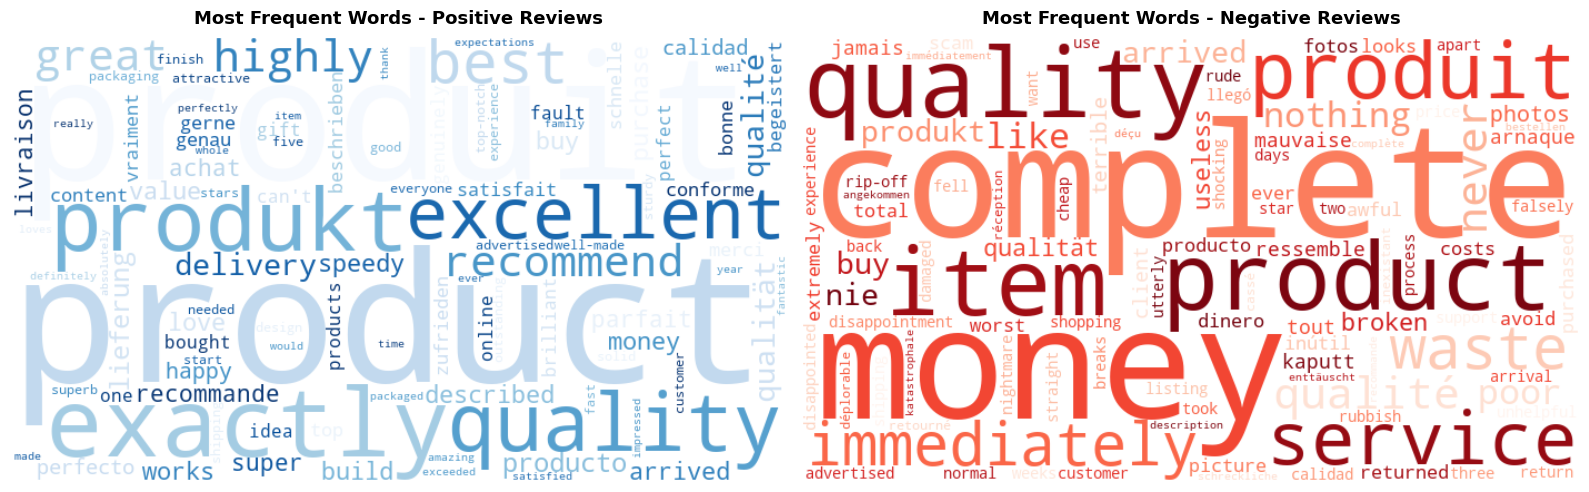

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive word cloud
pos_words = dict(clean_and_count(positive_text, n=100))
wc_pos = WordCloud(width=700, height=400, background_color='white',
                   colormap='Blues', max_words=100).generate_from_frequencies(pos_words)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Most Frequent Words - Positive Reviews',
                  fontsize=13, fontweight='bold', pad=10)
axes[0].axis('off')

# Negative word cloud
neg_words = dict(clean_and_count(negative_text, n=100))
wc_neg = WordCloud(width=700, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate_from_frequencies(neg_words)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Most Frequent Words - Negative Reviews',
                  fontsize=13, fontweight='bold', pad=10)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'sentiment_wordclouds.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight
"Quality" and "product" appear prominently in both word clouds, 
confirming they are the true battleground of customer experience. 
"Money" features strongly in negative reviews, signalling financial 
frustration, but does not rank among the top positive signals, 
suggesting customers rarely celebrate value when satisfied but 
loudly mention wasted money when disappointed.


## Top Words Comparison - Positive vs Negative
A direct side-by-side comparison of the most frequent words 
in positive and negative reviews.

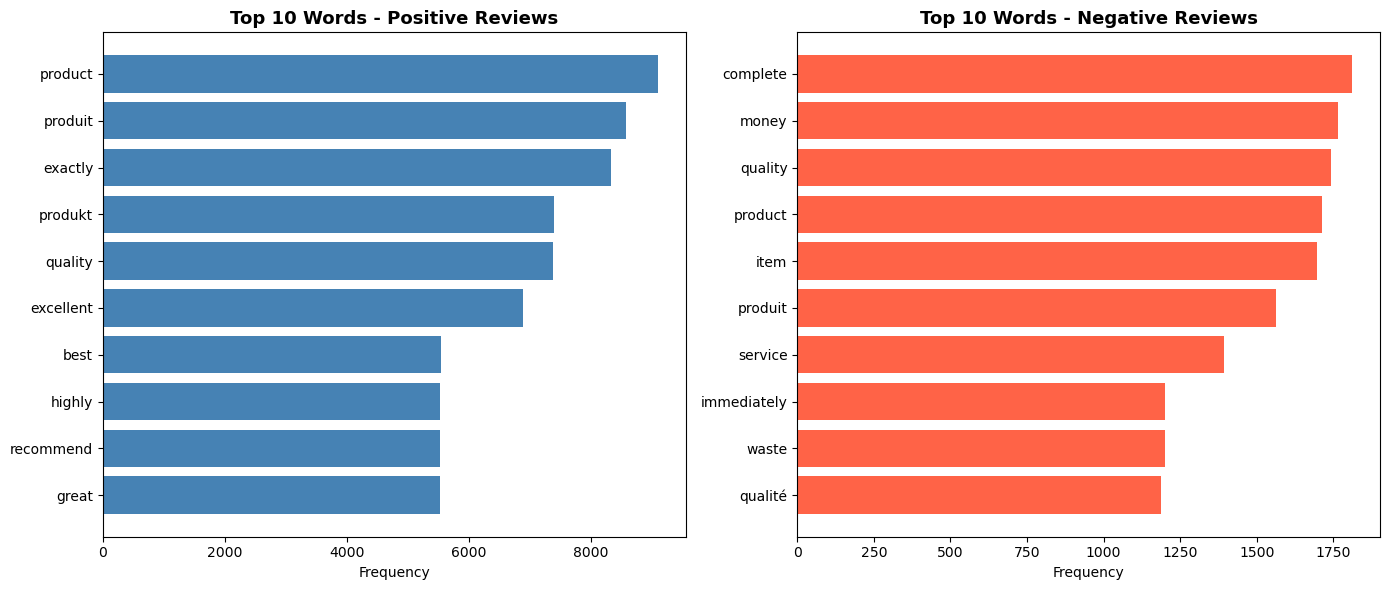

In [7]:
# Get top 10 words for each sentiment
pos_words = clean_and_count(positive_text, n=10)
neg_words = clean_and_count(negative_text, n=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive
pos_labels = [w[0] for w in pos_words]
pos_counts = [w[1] for w in pos_words]
axes[0].barh(pos_labels[::-1], pos_counts[::-1], color='steelblue')
axes[0].set_title('Top 10 Words - Positive Reviews',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].grid(False)

# Negative
neg_labels = [w[0] for w in neg_words]
neg_counts = [w[1] for w in neg_words]
axes[1].barh(neg_labels[::-1], neg_counts[::-1], color='tomato')
axes[1].set_title('Top 10 Words - Negative Reviews',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'top_words_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight

The vocabulary of satisfied and dissatisfied customers reveals 
distinctly different emotional journeys.

Positive reviews are anchored around product quality and met 
expectations, "exactly", "excellent", "recommend" and "great" 
suggest customers who received what was promised and want others 
to know. Delivery also features prominently, confirming that 
speed and reliability of fulfilment is a key satisfaction driver.

Negative reviews tell a story of disappointment and financial 
regret, "complete" likely appears in phrases like "complete waste" 
or "complete disappointment", while "money", "waste" and "immediately" 
suggest customers seeking refunds or replacements urgently. "Service" 
appearing in the negative top 10 but not the positive top 10 indicates 
that customer service is noticed primarily when it fails.

For ShopEase Europe's operations team, the actionable priorities are:
- Maintain product quality consistency: It drives both the strongest 
  praise and the loudest complaints
- Improve customer service responsiveness: It only enters the 
  conversation when customers are already unhappy
- Protect delivery reliability: It features in positive reviews 
  but its absence would likely generate negative mentions